In [1]:
import myQMLlib as myQML
import numpy as np
import matplotlib.pyplot as plt
import time

#Code to automatically reload the myQMLfunctions module when it is edited
%load_ext autoreload
%autoreload 2

-------- (Shots = 0, Realizations = 100) --------
Processing Realization 10/100...
Processing Realization 20/100...
Processing Realization 30/100...
Processing Realization 40/100...
Processing Realization 50/100...
Processing Realization 60/100...
Processing Realization 70/100...
Processing Realization 80/100...
Processing Realization 90/100...
Processing Realization 100/100...

--- Final Results ---
N = 10   | QELM MSE: 0.0000 | K-LE MSE: 0.0000 | K-SW MSE: 0.0000
N = 30   | QELM MSE: 0.0000 | K-LE MSE: 0.0000 | K-SW MSE: 0.0000
N = 50   | QELM MSE: 0.0000 | K-LE MSE: 0.0000 | K-SW MSE: 0.0000
N = 100  | QELM MSE: 0.0000 | K-LE MSE: 0.0000 | K-SW MSE: 0.0000
N = 500  | QELM MSE: 0.0000 | K-LE MSE: 0.0000 | K-SW MSE: 0.0000
N = 1000 | QELM MSE: 0.0000 | K-LE MSE: 0.0000 | K-SW MSE: 0.0000
Experiment finished in 13.3 minutes.


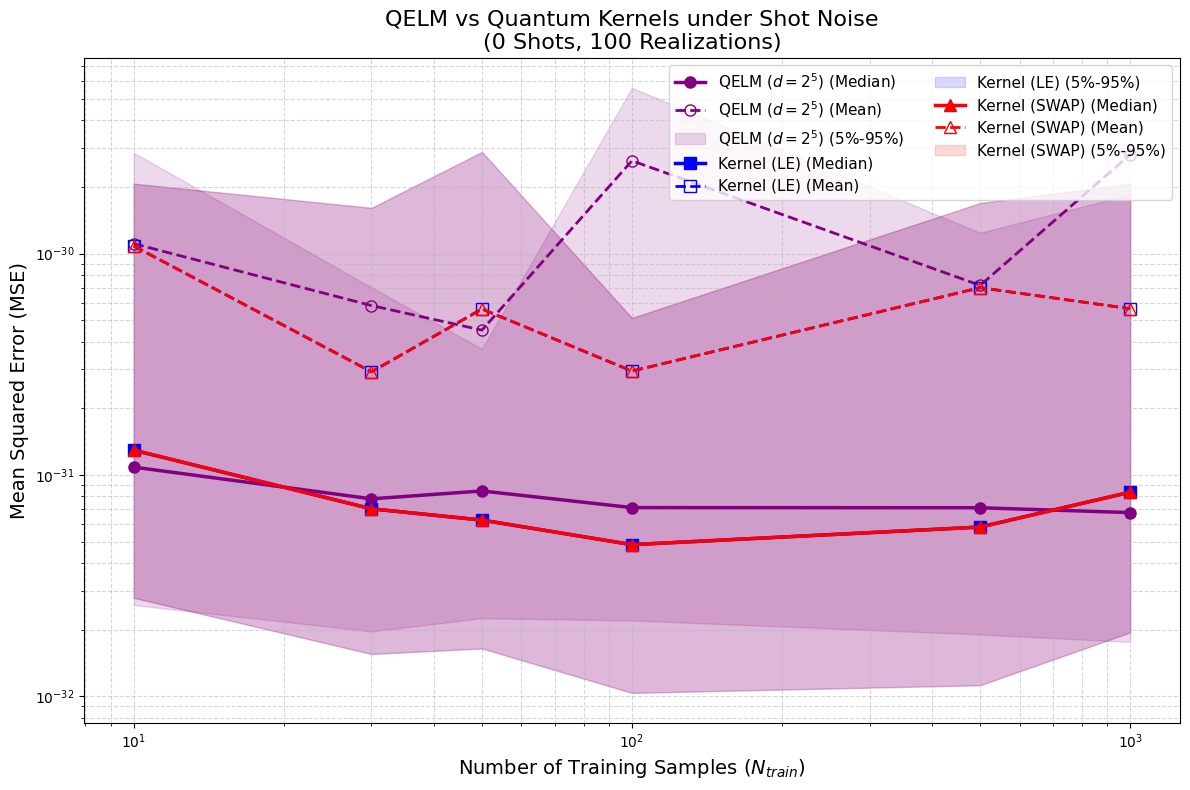

In [4]:
import time
import numpy as np
import matplotlib.pyplot as plt
# import myQML  # Assuming this is your module

####### Settings #########
N_train_list = [10, 30, 50, 100, 500, 1000]
N_max = max(N_train_list)  # Find the largest dataset size needed
N_test = 200
num_realizations = 100
num_shots = 0

reg_lambda = 0

# QELM reservoir physical setup
d_in = 2
d_res = 64
d_out = d_in * d_res
povm = myQML.generate_computational_povm(d_res) 
num_povm_elements = len(povm)

# Temporary nested dictionary to store MSE for each N_train inside the realizations
mse_runs = {
    'QELM': {N: [] for N in N_train_list},
    'Kernel_LE': {N: [] for N in N_train_list},
    'Kernel_SWAP': {N: [] for N in N_train_list}
}

# Storage dictionaries for final plotting
results_mean = {'QELM': [], 'Kernel_LE': [], 'Kernel_SWAP': []}
results_median = {'QELM': [], 'Kernel_LE': [], 'Kernel_SWAP': []}
quantiles_5 = {'QELM': [], 'Kernel_LE': [], 'Kernel_SWAP': []}
quantiles_95 = {'QELM': [], 'Kernel_LE': [], 'Kernel_SWAP': []}

print(f"-------- (Shots = {num_shots}, Realizations = {num_realizations}) --------")
print("="*70)

total_time = time.time()

# INVERTED LOOP: We do the realizations first to share the big dataset
for r in range(num_realizations):
    if (r + 1) % 10 == 0:
        print(f"Processing Realization {r + 1}/{num_realizations}...")
        
    # 1. Generate the LARGEST dataset just once
    ds = myQML.QuantumDatasetGenerator(N_max, N_test, myQML.X)
    ds.generate_density_matrices_vec()
    ds.compute_expectation_values_vec()

    rho_train_full, y_train_full = ds.get_training_dataset()
    rho_test, y_test = ds.get_test_dataset()

    # 2. Fit the Kernel methods on the FULL largest dataset 
    # (This computes the full N_max x N_max matrix once)
    kernel_le_full = myQML.QuantumKernelRegression(reg_lambda, num_shots)
    kernel_le_full.fit_vec(rho_train_full, y_train_full, "le")
    K_matrix_le_full = kernel_le_full.kernel_matrix  # Grab the regularized matrix

    kernel_swap_full = myQML.QuantumKernelRegression(reg_lambda, num_shots)
    kernel_swap_full.fit_vec(rho_train_full, y_train_full, "swap")
    K_matrix_swap_full = kernel_swap_full.kernel_matrix

    # 3. Setup QELM for this realization
    V = myQML.random_isometry(d_in, d_in * d_res)
    qelm = myQML.QuantumExtremeLearningMachine(
        isometry=V, 
        povm=povm, 
        bipartite_dims=(d_in, d_res), 
        keep_subsystem=1, 
        num_shots=num_shots
    )

    # 4. Loop over subsets and SLICE the matrices/data
    for N_train in sorted(N_train_list, reverse=True):
        
        # Subset the physical data
        rho_train_sub = rho_train_full[:N_train]
        y_train_sub = y_train_full[:N_train]

        # --- QELM ---
        # (QELM fitting itself is very fast; bypassing data generation already speeds it up 10x)
        qelm.fit_vec(rho_train_sub, y_train_sub)
        mse_runs['QELM'][N_train].append(np.mean((qelm.predict_vec(rho_test) - y_test)**2))
        
        # --- Kernel LE ---
        # Slice the upper-left N x N submatrix (diagonal retains the reg_lambda)
        K_le_sub = K_matrix_le_full[:N_train, :N_train]
        K_le_inv_sub = np.linalg.pinv(K_le_sub, rcond=kernel_le_full.r_cond)
        alpha_le_sub = K_le_inv_sub @ y_train_sub

        # Manually inject subset parameters back into the model to allow for standard predict_vec calls
        kernel_le_full.train_density_matrices = rho_train_sub
        kernel_le_full.train_labels = y_train_sub
        kernel_le_full.kernel_matrix = K_le_sub
        kernel_le_full.K_inv = K_le_inv_sub
        kernel_le_full.alpha = alpha_le_sub
        
        mse_runs['Kernel_LE'][N_train].append(np.mean((kernel_le_full.predict_vec(rho_test) - y_test)**2))

        # --- Kernel SWAP ---
        K_swap_sub = K_matrix_swap_full[:N_train, :N_train]
        K_swap_inv_sub = np.linalg.pinv(K_swap_sub, rcond=kernel_swap_full.r_cond)
        alpha_swap_sub = K_swap_inv_sub @ y_train_sub

        # Inject
        kernel_swap_full.train_density_matrices = rho_train_sub
        kernel_swap_full.train_labels = y_train_sub
        kernel_swap_full.kernel_matrix = K_swap_sub
        kernel_swap_full.K_inv = K_swap_inv_sub
        kernel_swap_full.alpha = alpha_swap_sub
        
        mse_runs['Kernel_SWAP'][N_train].append(np.mean((kernel_swap_full.predict_vec(rho_test) - y_test)**2))

# ==========================================
# Post-Processing and Aggregation
# ==========================================
print("\n--- Final Results ---")
for N_train in N_train_list:
    for model in ['QELM', 'Kernel_LE', 'Kernel_SWAP']:
        data = mse_runs[model][N_train]
        results_mean[model].append(np.mean(data))
        results_median[model].append(np.median(data))
        quantiles_5[model].append(np.percentile(data, 5))
        quantiles_95[model].append(np.percentile(data, 95))
        
    print(f"N = {N_train:<4d} | QELM MSE: {results_mean['QELM'][-1]:.4f} | K-LE MSE: {results_mean['Kernel_LE'][-1]:.4f} | K-SW MSE: {results_mean['Kernel_SWAP'][-1]:.4f}")

print("="*70)
print(f"Experiment finished in {(time.time() - total_time)/60:.1f} minutes.")


# ==========================================
# Single Combined Plot
# ==========================================
plt.figure(figsize=(12, 8))
N_arr = np.array(N_train_list)

colors = {'QELM': 'purple', 'Kernel_LE': 'blue', 'Kernel_SWAP': 'red'}
labels = {'QELM': 'QELM ($d=2^5$)', 
          'Kernel_LE': 'Kernel (LE)', 
          'Kernel_SWAP': 'Kernel (SWAP)'}
markers = {'QELM': 'o', 'Kernel_LE': 's', 'Kernel_SWAP': '^'}

for model in results_mean.keys():
    mean_arr = np.array(results_mean[model])
    median_arr = np.array(results_median[model])
    q5_arr = np.array(quantiles_5[model])
    q95_arr = np.array(quantiles_95[model])
    
    # 1. Plot the Median (Solid line)
    plt.plot(N_arr, median_arr, label=f'{labels[model]} (Median)', color=colors[model], 
             marker=markers[model], linestyle='-', linewidth=2.5, markersize=8)
    
    # 2. Plot the Mean (Dashed line, empty markers to differentiate from median)
    plt.plot(N_arr, mean_arr, label=f'{labels[model]} (Mean)', color=colors[model], 
             marker=markers[model], linestyle='--', linewidth=2.0, markersize=8, fillstyle='none')
    
    # 3. Fill between 5% and 95% quantiles
    plt.fill_between(N_arr, q5_arr, q95_arr, color=colors[model], alpha=0.15, 
                     label=f'{labels[model]} (5%-95%)') 

plt.xscale('log')
plt.yscale('log')
plt.xlabel('Number of Training Samples ($N_{train}$)', fontsize=14)
plt.ylabel('Mean Squared Error (MSE)', fontsize=14)
plt.title(f'QELM vs Quantum Kernels under Shot Noise\n({num_shots} Shots, {num_realizations} Realizations)', fontsize=16)
plt.grid(True, which="both", ls="--", alpha=0.5)

# Place legend outside the plot if it gets too crowded, or use 2 columns
plt.legend(fontsize=11, ncol=2, loc='upper right') 
plt.tight_layout()
plt.show()

-------- (Shots = 10, Realizations = 100) --------
Processing Realization 10/100...
Processing Realization 20/100...
Processing Realization 30/100...
Processing Realization 40/100...
Processing Realization 50/100...
Processing Realization 60/100...
Processing Realization 70/100...
Processing Realization 80/100...
Processing Realization 90/100...
Processing Realization 100/100...

--- Final Results ---
N = 10   | QELM MSE: 0.1853 | K-LE MSE: 40.0164 | K-SW MSE: 19.1111
N = 30   | QELM MSE: 0.2737 | K-LE MSE: 329.0033 | K-SW MSE: 50.0971
N = 50   | QELM MSE: 0.7183 | K-LE MSE: 2976.2083 | K-SW MSE: 824.0098
N = 100  | QELM MSE: 0.3572 | K-LE MSE: 160.1031 | K-SW MSE: 457.3621
N = 500  | QELM MSE: 0.1414 | K-LE MSE: 1840.8063 | K-SW MSE: 83.0429
N = 1000 | QELM MSE: 0.1306 | K-LE MSE: 20.3430 | K-SW MSE: 1085.6931
Experiment finished in 45.7 minutes.


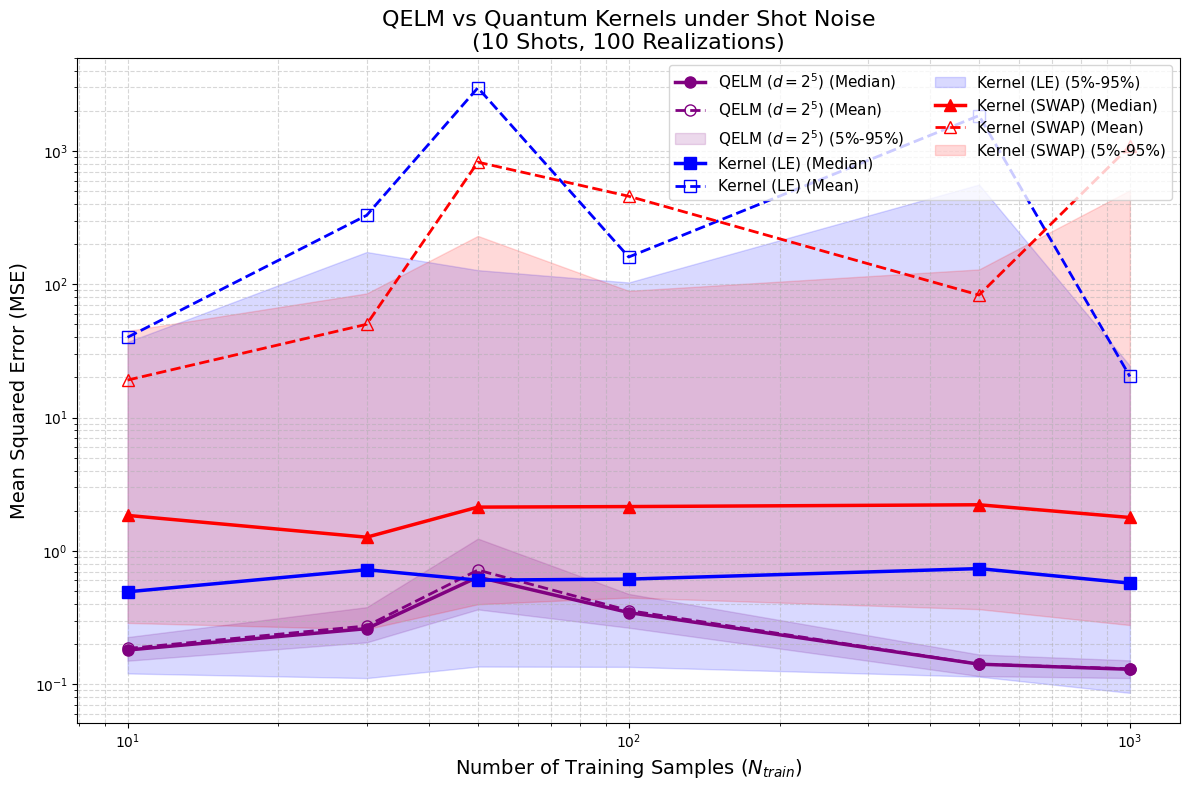

In [5]:
import time
import numpy as np
import matplotlib.pyplot as plt
# import myQML  # Assuming this is your module

####### Settings #########
N_train_list = [10, 30, 50, 100, 500, 1000]
N_max = max(N_train_list)  # Find the largest dataset size needed
N_test = 200
num_realizations = 100
num_shots = 10

reg_lambda = 0

# QELM reservoir physical setup
d_in = 2
d_res = 64
d_out = d_in * d_res
povm = myQML.generate_computational_povm(d_res) 
num_povm_elements = len(povm)

# Temporary nested dictionary to store MSE for each N_train inside the realizations
mse_runs = {
    'QELM': {N: [] for N in N_train_list},
    'Kernel_LE': {N: [] for N in N_train_list},
    'Kernel_SWAP': {N: [] for N in N_train_list}
}

# Storage dictionaries for final plotting
results_mean = {'QELM': [], 'Kernel_LE': [], 'Kernel_SWAP': []}
results_median = {'QELM': [], 'Kernel_LE': [], 'Kernel_SWAP': []}
quantiles_5 = {'QELM': [], 'Kernel_LE': [], 'Kernel_SWAP': []}
quantiles_95 = {'QELM': [], 'Kernel_LE': [], 'Kernel_SWAP': []}

print(f"-------- (Shots = {num_shots}, Realizations = {num_realizations}) --------")
print("="*70)

total_time = time.time()

# INVERTED LOOP: We do the realizations first to share the big dataset
for r in range(num_realizations):
    if (r + 1) % 10 == 0:
        print(f"Processing Realization {r + 1}/{num_realizations}...")
        
    # 1. Generate the LARGEST dataset just once
    ds = myQML.QuantumDatasetGenerator(N_max, N_test, myQML.X)
    ds.generate_density_matrices_vec()
    ds.compute_expectation_values_vec()

    rho_train_full, y_train_full = ds.get_training_dataset()
    rho_test, y_test = ds.get_test_dataset()

    # 2. Fit the Kernel methods on the FULL largest dataset 
    # (This computes the full N_max x N_max matrix once)
    kernel_le_full = myQML.QuantumKernelRegression(reg_lambda, num_shots)
    kernel_le_full.fit_vec(rho_train_full, y_train_full, "le")
    K_matrix_le_full = kernel_le_full.kernel_matrix  # Grab the regularized matrix

    kernel_swap_full = myQML.QuantumKernelRegression(reg_lambda, num_shots)
    kernel_swap_full.fit_vec(rho_train_full, y_train_full, "swap")
    K_matrix_swap_full = kernel_swap_full.kernel_matrix

    # 3. Setup QELM for this realization
    V = myQML.random_isometry(d_in, d_in * d_res)
    qelm = myQML.QuantumExtremeLearningMachine(
        isometry=V, 
        povm=povm, 
        bipartite_dims=(d_in, d_res), 
        keep_subsystem=1, 
        num_shots=num_shots
    )

    # 4. Loop over subsets and SLICE the matrices/data
    for N_train in sorted(N_train_list, reverse=True):
        
        # Subset the physical data
        rho_train_sub = rho_train_full[:N_train]
        y_train_sub = y_train_full[:N_train]

        # --- QELM ---
        # (QELM fitting itself is very fast; bypassing data generation already speeds it up 10x)
        qelm.fit_vec(rho_train_sub, y_train_sub)
        mse_runs['QELM'][N_train].append(np.mean((qelm.predict_vec(rho_test) - y_test)**2))
        
        # --- Kernel LE ---
        # Slice the upper-left N x N submatrix (diagonal retains the reg_lambda)
        K_le_sub = K_matrix_le_full[:N_train, :N_train]
        K_le_inv_sub = np.linalg.pinv(K_le_sub, rcond=kernel_le_full.r_cond)
        alpha_le_sub = K_le_inv_sub @ y_train_sub

        # Manually inject subset parameters back into the model to allow for standard predict_vec calls
        kernel_le_full.train_density_matrices = rho_train_sub
        kernel_le_full.train_labels = y_train_sub
        kernel_le_full.kernel_matrix = K_le_sub
        kernel_le_full.K_inv = K_le_inv_sub
        kernel_le_full.alpha = alpha_le_sub
        
        mse_runs['Kernel_LE'][N_train].append(np.mean((kernel_le_full.predict_vec(rho_test) - y_test)**2))

        # --- Kernel SWAP ---
        K_swap_sub = K_matrix_swap_full[:N_train, :N_train]
        K_swap_inv_sub = np.linalg.pinv(K_swap_sub, rcond=kernel_swap_full.r_cond)
        alpha_swap_sub = K_swap_inv_sub @ y_train_sub

        # Inject
        kernel_swap_full.train_density_matrices = rho_train_sub
        kernel_swap_full.train_labels = y_train_sub
        kernel_swap_full.kernel_matrix = K_swap_sub
        kernel_swap_full.K_inv = K_swap_inv_sub
        kernel_swap_full.alpha = alpha_swap_sub
        
        mse_runs['Kernel_SWAP'][N_train].append(np.mean((kernel_swap_full.predict_vec(rho_test) - y_test)**2))

# ==========================================
# Post-Processing and Aggregation
# ==========================================
print("\n--- Final Results ---")
for N_train in N_train_list:
    for model in ['QELM', 'Kernel_LE', 'Kernel_SWAP']:
        data = mse_runs[model][N_train]
        results_mean[model].append(np.mean(data))
        results_median[model].append(np.median(data))
        quantiles_5[model].append(np.percentile(data, 5))
        quantiles_95[model].append(np.percentile(data, 95))
        
    print(f"N = {N_train:<4d} | QELM MSE: {results_mean['QELM'][-1]:.4f} | K-LE MSE: {results_mean['Kernel_LE'][-1]:.4f} | K-SW MSE: {results_mean['Kernel_SWAP'][-1]:.4f}")

print("="*70)
print(f"Experiment finished in {(time.time() - total_time)/60:.1f} minutes.")


# ==========================================
# Single Combined Plot
# ==========================================
plt.figure(figsize=(12, 8))
N_arr = np.array(N_train_list)

colors = {'QELM': 'purple', 'Kernel_LE': 'blue', 'Kernel_SWAP': 'red'}
labels = {'QELM': 'QELM ($d=2^5$)', 
          'Kernel_LE': 'Kernel (LE)', 
          'Kernel_SWAP': 'Kernel (SWAP)'}
markers = {'QELM': 'o', 'Kernel_LE': 's', 'Kernel_SWAP': '^'}

for model in results_mean.keys():
    mean_arr = np.array(results_mean[model])
    median_arr = np.array(results_median[model])
    q5_arr = np.array(quantiles_5[model])
    q95_arr = np.array(quantiles_95[model])
    
    # 1. Plot the Median (Solid line)
    plt.plot(N_arr, median_arr, label=f'{labels[model]} (Median)', color=colors[model], 
             marker=markers[model], linestyle='-', linewidth=2.5, markersize=8)
    
    # 2. Plot the Mean (Dashed line, empty markers to differentiate from median)
    plt.plot(N_arr, mean_arr, label=f'{labels[model]} (Mean)', color=colors[model], 
             marker=markers[model], linestyle='--', linewidth=2.0, markersize=8, fillstyle='none')
    
    # 3. Fill between 5% and 95% quantiles
    plt.fill_between(N_arr, q5_arr, q95_arr, color=colors[model], alpha=0.15, 
                     label=f'{labels[model]} (5%-95%)') 

plt.xscale('log')
plt.yscale('log')
plt.xlabel('Number of Training Samples ($N_{train}$)', fontsize=14)
plt.ylabel('Mean Squared Error (MSE)', fontsize=14)
plt.title(f'QELM vs Quantum Kernels under Shot Noise\n({num_shots} Shots, {num_realizations} Realizations)', fontsize=16)
plt.grid(True, which="both", ls="--", alpha=0.5)

# Place legend outside the plot if it gets too crowded, or use 2 columns
plt.legend(fontsize=11, ncol=2, loc='upper right') 
plt.tight_layout()
plt.show()

-------- (Shots = 100, Realizations = 100) --------
Processing Realization 10/100...
Processing Realization 20/100...
Processing Realization 30/100...
Processing Realization 40/100...
Processing Realization 50/100...
Processing Realization 60/100...
Processing Realization 70/100...
Processing Realization 80/100...
Processing Realization 90/100...
Processing Realization 100/100...

--- Final Results ---
N = 10   | QELM MSE: 0.1118 | K-LE MSE: 5222.8181 | K-SW MSE: 7.6103
N = 30   | QELM MSE: 0.0956 | K-LE MSE: 31.3295 | K-SW MSE: 268.8752
N = 50   | QELM MSE: 0.1966 | K-LE MSE: 3.9277 | K-SW MSE: 16.7410
N = 100  | QELM MSE: 0.1099 | K-LE MSE: 1.3466 | K-SW MSE: 3.5359
N = 500  | QELM MSE: 0.0447 | K-LE MSE: 20.4354 | K-SW MSE: 1.5348
N = 1000 | QELM MSE: 0.0412 | K-LE MSE: 64.6606 | K-SW MSE: 16.2172
Experiment finished in 16.7 minutes.


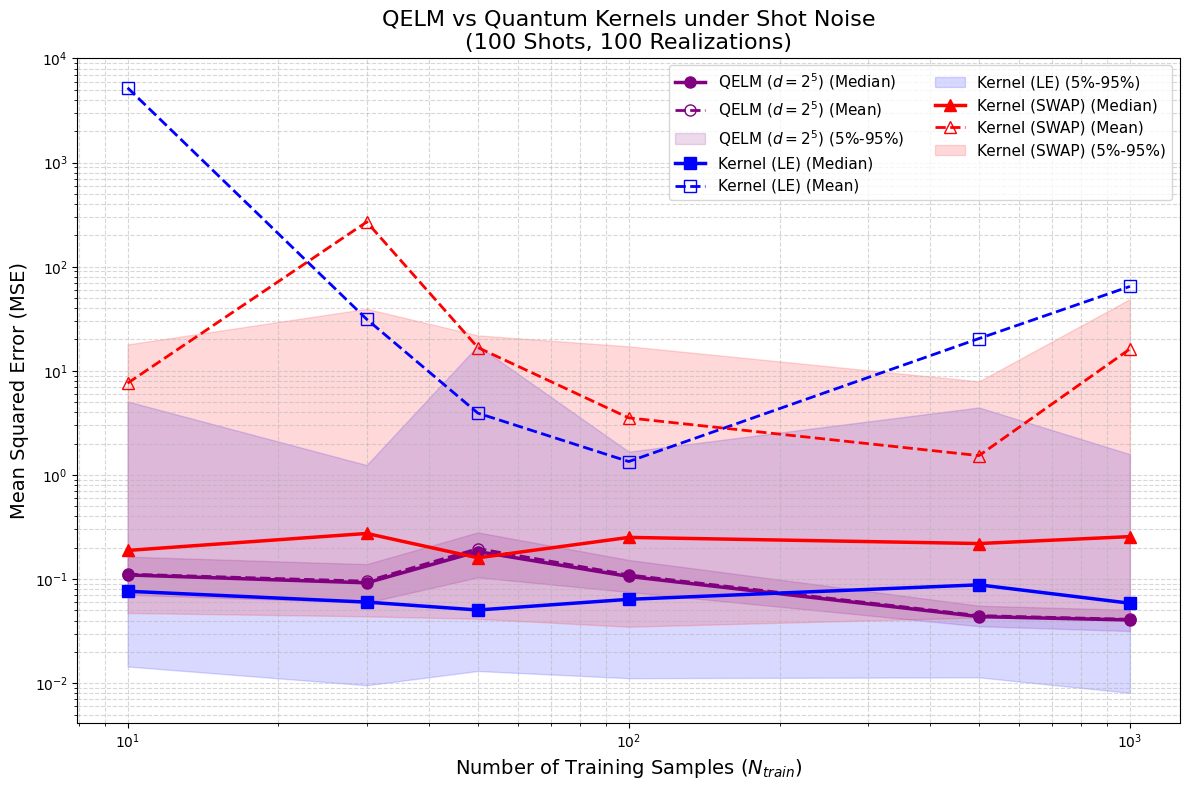

In [6]:
import time
import numpy as np
import matplotlib.pyplot as plt
# import myQML  # Assuming this is your module

####### Settings #########
N_train_list = [10, 30, 50, 100, 500, 1000]
N_max = max(N_train_list)  # Find the largest dataset size needed
N_test = 200
num_realizations = 100
num_shots = 100

reg_lambda = 0

# QELM reservoir physical setup
d_in = 2
d_res = 64
d_out = d_in * d_res
povm = myQML.generate_computational_povm(d_res) 
num_povm_elements = len(povm)

# Temporary nested dictionary to store MSE for each N_train inside the realizations
mse_runs = {
    'QELM': {N: [] for N in N_train_list},
    'Kernel_LE': {N: [] for N in N_train_list},
    'Kernel_SWAP': {N: [] for N in N_train_list}
}

# Storage dictionaries for final plotting
results_mean = {'QELM': [], 'Kernel_LE': [], 'Kernel_SWAP': []}
results_median = {'QELM': [], 'Kernel_LE': [], 'Kernel_SWAP': []}
quantiles_5 = {'QELM': [], 'Kernel_LE': [], 'Kernel_SWAP': []}
quantiles_95 = {'QELM': [], 'Kernel_LE': [], 'Kernel_SWAP': []}

print(f"-------- (Shots = {num_shots}, Realizations = {num_realizations}) --------")
print("="*70)

total_time = time.time()

# INVERTED LOOP: We do the realizations first to share the big dataset
for r in range(num_realizations):
    if (r + 1) % 10 == 0:
        print(f"Processing Realization {r + 1}/{num_realizations}...")
        
    # 1. Generate the LARGEST dataset just once
    ds = myQML.QuantumDatasetGenerator(N_max, N_test, myQML.X)
    ds.generate_density_matrices_vec()
    ds.compute_expectation_values_vec()

    rho_train_full, y_train_full = ds.get_training_dataset()
    rho_test, y_test = ds.get_test_dataset()

    # 2. Fit the Kernel methods on the FULL largest dataset 
    # (This computes the full N_max x N_max matrix once)
    kernel_le_full = myQML.QuantumKernelRegression(reg_lambda, num_shots)
    kernel_le_full.fit_vec(rho_train_full, y_train_full, "le")
    K_matrix_le_full = kernel_le_full.kernel_matrix  # Grab the regularized matrix

    kernel_swap_full = myQML.QuantumKernelRegression(reg_lambda, num_shots)
    kernel_swap_full.fit_vec(rho_train_full, y_train_full, "swap")
    K_matrix_swap_full = kernel_swap_full.kernel_matrix

    # 3. Setup QELM for this realization
    V = myQML.random_isometry(d_in, d_in * d_res)
    qelm = myQML.QuantumExtremeLearningMachine(
        isometry=V, 
        povm=povm, 
        bipartite_dims=(d_in, d_res), 
        keep_subsystem=1, 
        num_shots=num_shots
    )

    # 4. Loop over subsets and SLICE the matrices/data
    for N_train in sorted(N_train_list, reverse=True):
        
        # Subset the physical data
        rho_train_sub = rho_train_full[:N_train]
        y_train_sub = y_train_full[:N_train]

        # --- QELM ---
        # (QELM fitting itself is very fast; bypassing data generation already speeds it up 10x)
        qelm.fit_vec(rho_train_sub, y_train_sub)
        mse_runs['QELM'][N_train].append(np.mean((qelm.predict_vec(rho_test) - y_test)**2))
        
        # --- Kernel LE ---
        # Slice the upper-left N x N submatrix (diagonal retains the reg_lambda)
        K_le_sub = K_matrix_le_full[:N_train, :N_train]
        K_le_inv_sub = np.linalg.pinv(K_le_sub, rcond=kernel_le_full.r_cond)
        alpha_le_sub = K_le_inv_sub @ y_train_sub

        # Manually inject subset parameters back into the model to allow for standard predict_vec calls
        kernel_le_full.train_density_matrices = rho_train_sub
        kernel_le_full.train_labels = y_train_sub
        kernel_le_full.kernel_matrix = K_le_sub
        kernel_le_full.K_inv = K_le_inv_sub
        kernel_le_full.alpha = alpha_le_sub
        
        mse_runs['Kernel_LE'][N_train].append(np.mean((kernel_le_full.predict_vec(rho_test) - y_test)**2))

        # --- Kernel SWAP ---
        K_swap_sub = K_matrix_swap_full[:N_train, :N_train]
        K_swap_inv_sub = np.linalg.pinv(K_swap_sub, rcond=kernel_swap_full.r_cond)
        alpha_swap_sub = K_swap_inv_sub @ y_train_sub

        # Inject
        kernel_swap_full.train_density_matrices = rho_train_sub
        kernel_swap_full.train_labels = y_train_sub
        kernel_swap_full.kernel_matrix = K_swap_sub
        kernel_swap_full.K_inv = K_swap_inv_sub
        kernel_swap_full.alpha = alpha_swap_sub
        
        mse_runs['Kernel_SWAP'][N_train].append(np.mean((kernel_swap_full.predict_vec(rho_test) - y_test)**2))

# ==========================================
# Post-Processing and Aggregation
# ==========================================
print("\n--- Final Results ---")
for N_train in N_train_list:
    for model in ['QELM', 'Kernel_LE', 'Kernel_SWAP']:
        data = mse_runs[model][N_train]
        results_mean[model].append(np.mean(data))
        results_median[model].append(np.median(data))
        quantiles_5[model].append(np.percentile(data, 5))
        quantiles_95[model].append(np.percentile(data, 95))
        
    print(f"N = {N_train:<4d} | QELM MSE: {results_mean['QELM'][-1]:.4f} | K-LE MSE: {results_mean['Kernel_LE'][-1]:.4f} | K-SW MSE: {results_mean['Kernel_SWAP'][-1]:.4f}")

print("="*70)
print(f"Experiment finished in {(time.time() - total_time)/60:.1f} minutes.")


# ==========================================
# Single Combined Plot
# ==========================================
plt.figure(figsize=(12, 8))
N_arr = np.array(N_train_list)

colors = {'QELM': 'purple', 'Kernel_LE': 'blue', 'Kernel_SWAP': 'red'}
labels = {'QELM': 'QELM ($d=2^5$)', 
          'Kernel_LE': 'Kernel (LE)', 
          'Kernel_SWAP': 'Kernel (SWAP)'}
markers = {'QELM': 'o', 'Kernel_LE': 's', 'Kernel_SWAP': '^'}

for model in results_mean.keys():
    mean_arr = np.array(results_mean[model])
    median_arr = np.array(results_median[model])
    q5_arr = np.array(quantiles_5[model])
    q95_arr = np.array(quantiles_95[model])
    
    # 1. Plot the Median (Solid line)
    plt.plot(N_arr, median_arr, label=f'{labels[model]} (Median)', color=colors[model], 
             marker=markers[model], linestyle='-', linewidth=2.5, markersize=8)
    
    # 2. Plot the Mean (Dashed line, empty markers to differentiate from median)
    plt.plot(N_arr, mean_arr, label=f'{labels[model]} (Mean)', color=colors[model], 
             marker=markers[model], linestyle='--', linewidth=2.0, markersize=8, fillstyle='none')
    
    # 3. Fill between 5% and 95% quantiles
    plt.fill_between(N_arr, q5_arr, q95_arr, color=colors[model], alpha=0.15, 
                     label=f'{labels[model]} (5%-95%)') 

plt.xscale('log')
plt.yscale('log')
plt.xlabel('Number of Training Samples ($N_{train}$)', fontsize=14)
plt.ylabel('Mean Squared Error (MSE)', fontsize=14)
plt.title(f'QELM vs Quantum Kernels under Shot Noise\n({num_shots} Shots, {num_realizations} Realizations)', fontsize=16)
plt.grid(True, which="both", ls="--", alpha=0.5)

# Place legend outside the plot if it gets too crowded, or use 2 columns
plt.legend(fontsize=11, ncol=2, loc='upper right') 
plt.tight_layout()
plt.show()

-------- (Shots = 1000, Realizations = 100) --------
Processing Realization 10/100...
Processing Realization 20/100...
Processing Realization 30/100...
Processing Realization 40/100...
Processing Realization 50/100...
Processing Realization 60/100...
Processing Realization 70/100...
Processing Realization 80/100...
Processing Realization 90/100...
Processing Realization 100/100...

--- Final Results ---
N = 10   | QELM MSE: 0.0180 | K-LE MSE: 1.9995 | K-SW MSE: 1.0048
N = 30   | QELM MSE: 0.0116 | K-LE MSE: 22.2448 | K-SW MSE: 2122.7647
N = 50   | QELM MSE: 0.0268 | K-LE MSE: 0.5358 | K-SW MSE: 0.3063
N = 100  | QELM MSE: 0.0143 | K-LE MSE: 0.1785 | K-SW MSE: 5.3218
N = 500  | QELM MSE: 0.0057 | K-LE MSE: 0.1398 | K-SW MSE: 2.8211
N = 1000 | QELM MSE: 0.0053 | K-LE MSE: 0.1412 | K-SW MSE: 0.3410
Experiment finished in 14.2 minutes.


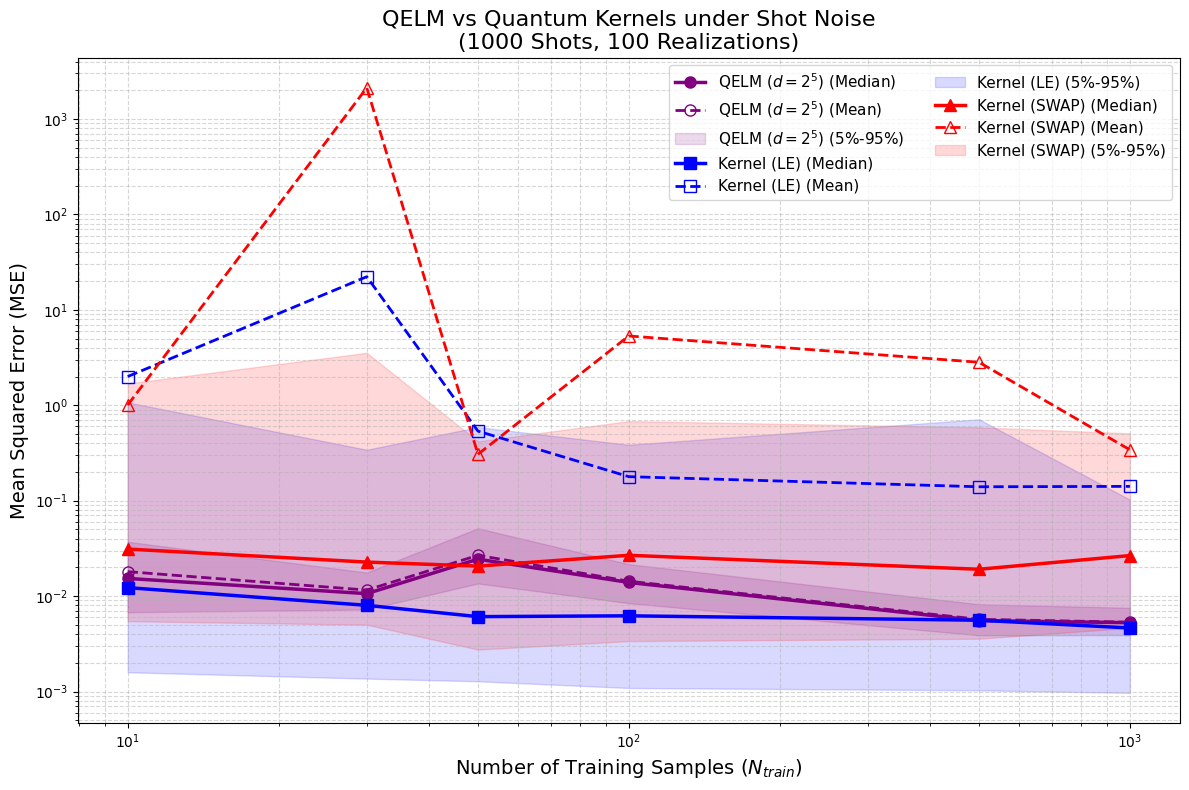

In [7]:
import time
import numpy as np
import matplotlib.pyplot as plt
# import myQML  # Assuming this is your module

####### Settings #########
N_train_list = [10, 30, 50, 100, 500, 1000]
N_max = max(N_train_list)  # Find the largest dataset size needed
N_test = 200
num_realizations = 100
num_shots = 1000

reg_lambda = 0

# QELM reservoir physical setup
d_in = 2
d_res = 64
d_out = d_in * d_res
povm = myQML.generate_computational_povm(d_res) 
num_povm_elements = len(povm)

# Temporary nested dictionary to store MSE for each N_train inside the realizations
mse_runs = {
    'QELM': {N: [] for N in N_train_list},
    'Kernel_LE': {N: [] for N in N_train_list},
    'Kernel_SWAP': {N: [] for N in N_train_list}
}

# Storage dictionaries for final plotting
results_mean = {'QELM': [], 'Kernel_LE': [], 'Kernel_SWAP': []}
results_median = {'QELM': [], 'Kernel_LE': [], 'Kernel_SWAP': []}
quantiles_5 = {'QELM': [], 'Kernel_LE': [], 'Kernel_SWAP': []}
quantiles_95 = {'QELM': [], 'Kernel_LE': [], 'Kernel_SWAP': []}

print(f"-------- (Shots = {num_shots}, Realizations = {num_realizations}) --------")
print("="*70)

total_time = time.time()

# INVERTED LOOP: We do the realizations first to share the big dataset
for r in range(num_realizations):
    if (r + 1) % 10 == 0:
        print(f"Processing Realization {r + 1}/{num_realizations}...")
        
    # 1. Generate the LARGEST dataset just once
    ds = myQML.QuantumDatasetGenerator(N_max, N_test, myQML.X)
    ds.generate_density_matrices_vec()
    ds.compute_expectation_values_vec()

    rho_train_full, y_train_full = ds.get_training_dataset()
    rho_test, y_test = ds.get_test_dataset()

    # 2. Fit the Kernel methods on the FULL largest dataset 
    # (This computes the full N_max x N_max matrix once)
    kernel_le_full = myQML.QuantumKernelRegression(reg_lambda, num_shots)
    kernel_le_full.fit_vec(rho_train_full, y_train_full, "le")
    K_matrix_le_full = kernel_le_full.kernel_matrix  # Grab the regularized matrix

    kernel_swap_full = myQML.QuantumKernelRegression(reg_lambda, num_shots)
    kernel_swap_full.fit_vec(rho_train_full, y_train_full, "swap")
    K_matrix_swap_full = kernel_swap_full.kernel_matrix

    # 3. Setup QELM for this realization
    V = myQML.random_isometry(d_in, d_in * d_res)
    qelm = myQML.QuantumExtremeLearningMachine(
        isometry=V, 
        povm=povm, 
        bipartite_dims=(d_in, d_res), 
        keep_subsystem=1, 
        num_shots=num_shots
    )

    # 4. Loop over subsets and SLICE the matrices/data
    for N_train in sorted(N_train_list, reverse=True):
        
        # Subset the physical data
        rho_train_sub = rho_train_full[:N_train]
        y_train_sub = y_train_full[:N_train]

        # --- QELM ---
        # (QELM fitting itself is very fast; bypassing data generation already speeds it up 10x)
        qelm.fit_vec(rho_train_sub, y_train_sub)
        mse_runs['QELM'][N_train].append(np.mean((qelm.predict_vec(rho_test) - y_test)**2))
        
        # --- Kernel LE ---
        # Slice the upper-left N x N submatrix (diagonal retains the reg_lambda)
        K_le_sub = K_matrix_le_full[:N_train, :N_train]
        K_le_inv_sub = np.linalg.pinv(K_le_sub, rcond=kernel_le_full.r_cond)
        alpha_le_sub = K_le_inv_sub @ y_train_sub

        # Manually inject subset parameters back into the model to allow for standard predict_vec calls
        kernel_le_full.train_density_matrices = rho_train_sub
        kernel_le_full.train_labels = y_train_sub
        kernel_le_full.kernel_matrix = K_le_sub
        kernel_le_full.K_inv = K_le_inv_sub
        kernel_le_full.alpha = alpha_le_sub
        
        mse_runs['Kernel_LE'][N_train].append(np.mean((kernel_le_full.predict_vec(rho_test) - y_test)**2))

        # --- Kernel SWAP ---
        K_swap_sub = K_matrix_swap_full[:N_train, :N_train]
        K_swap_inv_sub = np.linalg.pinv(K_swap_sub, rcond=kernel_swap_full.r_cond)
        alpha_swap_sub = K_swap_inv_sub @ y_train_sub

        # Inject
        kernel_swap_full.train_density_matrices = rho_train_sub
        kernel_swap_full.train_labels = y_train_sub
        kernel_swap_full.kernel_matrix = K_swap_sub
        kernel_swap_full.K_inv = K_swap_inv_sub
        kernel_swap_full.alpha = alpha_swap_sub
        
        mse_runs['Kernel_SWAP'][N_train].append(np.mean((kernel_swap_full.predict_vec(rho_test) - y_test)**2))

# ==========================================
# Post-Processing and Aggregation
# ==========================================
print("\n--- Final Results ---")
for N_train in N_train_list:
    for model in ['QELM', 'Kernel_LE', 'Kernel_SWAP']:
        data = mse_runs[model][N_train]
        results_mean[model].append(np.mean(data))
        results_median[model].append(np.median(data))
        quantiles_5[model].append(np.percentile(data, 5))
        quantiles_95[model].append(np.percentile(data, 95))
        
    print(f"N = {N_train:<4d} | QELM MSE: {results_mean['QELM'][-1]:.4f} | K-LE MSE: {results_mean['Kernel_LE'][-1]:.4f} | K-SW MSE: {results_mean['Kernel_SWAP'][-1]:.4f}")

print("="*70)
print(f"Experiment finished in {(time.time() - total_time)/60:.1f} minutes.")


# ==========================================
# Single Combined Plot
# ==========================================
plt.figure(figsize=(12, 8))
N_arr = np.array(N_train_list)

colors = {'QELM': 'purple', 'Kernel_LE': 'blue', 'Kernel_SWAP': 'red'}
labels = {'QELM': 'QELM ($d=2^5$)', 
          'Kernel_LE': 'Kernel (LE)', 
          'Kernel_SWAP': 'Kernel (SWAP)'}
markers = {'QELM': 'o', 'Kernel_LE': 's', 'Kernel_SWAP': '^'}

for model in results_mean.keys():
    mean_arr = np.array(results_mean[model])
    median_arr = np.array(results_median[model])
    q5_arr = np.array(quantiles_5[model])
    q95_arr = np.array(quantiles_95[model])
    
    # 1. Plot the Median (Solid line)
    plt.plot(N_arr, median_arr, label=f'{labels[model]} (Median)', color=colors[model], 
             marker=markers[model], linestyle='-', linewidth=2.5, markersize=8)
    
    # 2. Plot the Mean (Dashed line, empty markers to differentiate from median)
    plt.plot(N_arr, mean_arr, label=f'{labels[model]} (Mean)', color=colors[model], 
             marker=markers[model], linestyle='--', linewidth=2.0, markersize=8, fillstyle='none')
    
    # 3. Fill between 5% and 95% quantiles
    plt.fill_between(N_arr, q5_arr, q95_arr, color=colors[model], alpha=0.15, 
                     label=f'{labels[model]} (5%-95%)') 

plt.xscale('log')
plt.yscale('log')
plt.xlabel('Number of Training Samples ($N_{train}$)', fontsize=14)
plt.ylabel('Mean Squared Error (MSE)', fontsize=14)
plt.title(f'QELM vs Quantum Kernels under Shot Noise\n({num_shots} Shots, {num_realizations} Realizations)', fontsize=16)
plt.grid(True, which="both", ls="--", alpha=0.5)

# Place legend outside the plot if it gets too crowded, or use 2 columns
plt.legend(fontsize=11, ncol=2, loc='upper right') 
plt.tight_layout()
plt.show()